# Make a good looking four plot

plot the discount factores, zero rates, price and ytm differences

In [2]:
# Libraries and directories
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
from pathlib import Path

# Change working directory to the project root
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)
    
PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

print("PROJECT ROOT:", PROJECT_ROOT)



PROJECT ROOT: c:\Users\samla\zcb_treasury_curve


In [9]:
# Data uploading

zero_rates = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'zero_rates_discount_factors.csv')
results = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'result_table.csv')
results['Time to Maturity (Years)'] = results['Maturity'].apply(lambda x: (pd.to_datetime(x) - pd.to_datetime('2026-09-04')).days / 365.25)

print(zero_rates.head())
print(results.head())


   Time to Maturity (Years)  Zero Rate  Discount Factor
0                  0.030116   0.037362         0.998875
1                  0.071184   0.037574         0.997329
2                  0.112252   0.037781         0.995768
3                  0.156057   0.037996         0.994088
4                  0.197125   0.038192         0.992500
     Maturity  Coupon  Observed Dirty Price  Model Dirty Price  Difference  \
0  2026-09-15   4.625            102.205503         102.197443    0.008060   
1  2026-09-30   0.875            100.211279         100.169221    0.042058   
2  2026-09-30   1.625            100.595500         100.543219    0.052281   
3  2026-09-30   3.500            101.493554         101.478215    0.015338   
4  2026-10-15   4.625            101.892055         101.879512    0.012543   

   Observed Yield  Model Yield  Yield Difference  Time to Maturity (Years)  
0           2.937     3.771292          0.834292                  0.030116  
1           3.625     3.792925          0

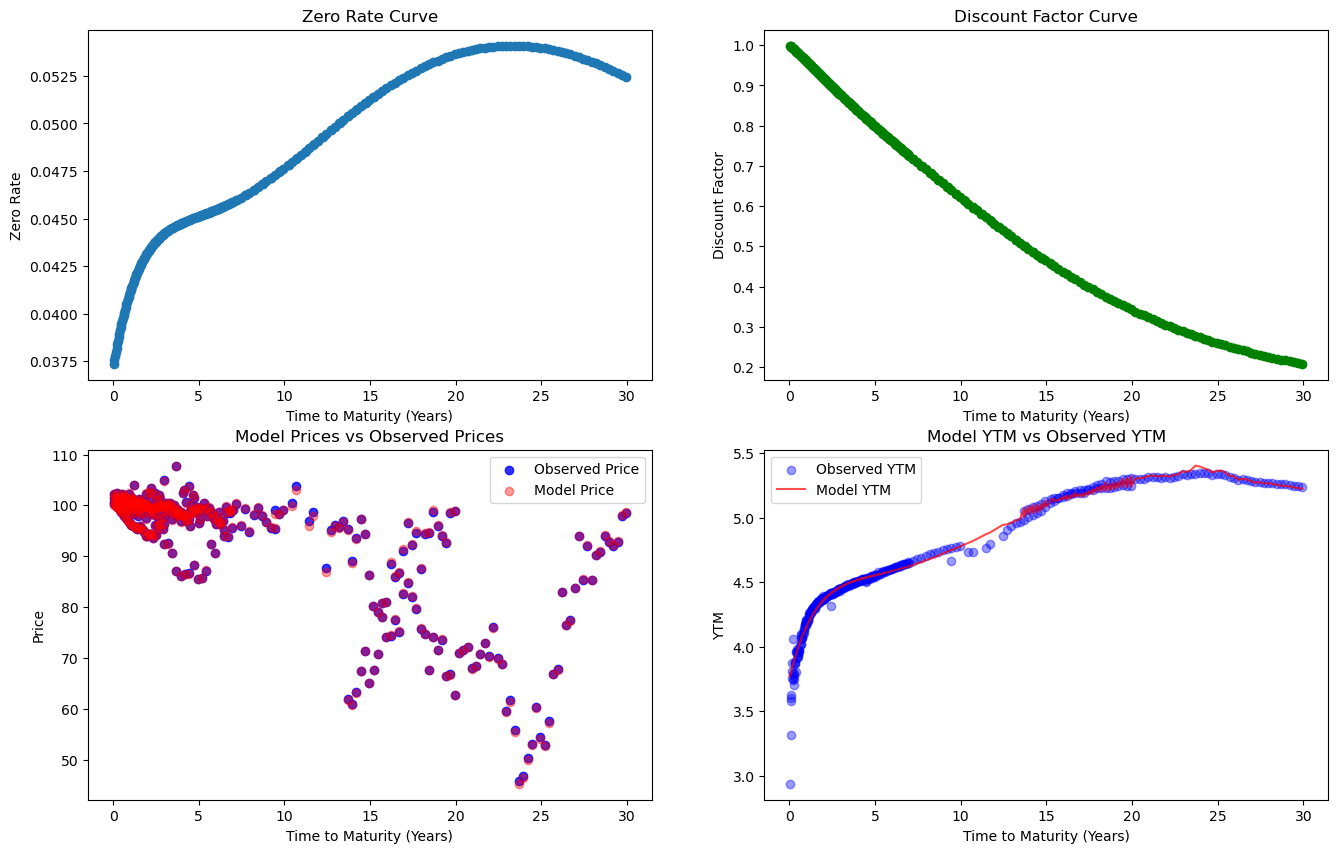

In [25]:
# plots
# make a 4 plot figure with 2 rows and 2 columns
plt.figure(figsize=(16, 10))
plt.subplot(2, 2, 1)
# zero rate curve
plt.plot(zero_rates['Time to Maturity (Years)'], zero_rates['Zero Rate'], marker='o')
plt.title('Zero Rate Curve')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Zero Rate')
# discount factor curve
plt.subplot(2, 2, 2)
plt.plot(zero_rates['Time to Maturity (Years)'], zero_rates['Discount Factor'], marker='o', color = 'green')
plt.title('Discount Factor Curve')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Discount Factor')
# model prices vs market prices
plt.subplot(2, 2, 3)
plt.scatter(results['Time to Maturity (Years)'], results['Observed Dirty Price'], marker='o', color = 'blue', label='Observed Price', alpha = 0.8)
plt.scatter(results['Time to Maturity (Years)'], results['Model Dirty Price'], marker='o', color = 'red', label='Model Price', alpha = 0.4)

plt.title('Model Prices vs Observed Prices')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Price')
plt.legend()
# model YTM vs market YTM
plt.subplot(2, 2, 4)
plt.scatter(results['Time to Maturity (Years)'], results['Observed Yield'], marker='o', color = 'blue', label='Observed YTM', alpha = 0.4)
plt.plot(results['Time to Maturity (Years)'], results['Model Yield'],  label='Model YTM', alpha = 0.7, color = 'red')

plt.title('Model YTM vs Observed YTM')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('YTM')
plt.legend()
